# Titanic Survival Prediction — First Classification Model

**Goal:** Train a Logistic Regression model to predict whether a passenger
survived the Titanic disaster, using the cleaned dataset from Task 2.

This is a binary classification problem: `Survived` is 0 (No) or 1 (Yes).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

df = pd.read_csv("titanic.csv")
df.shape


(891, 12)

## 2. Clean the data (same approach as Task 2)

In [2]:
df_clean = df.copy()

# Age: median by Pclass + Sex
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Cabin: turn into a HasCabin flag, then drop raw column
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])

# Embarked: fill with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean.isnull().sum().sum()  # should be 0


np.int64(0)

## 3. Select features and encode categorical columns

I drop columns that aren't useful as raw model inputs (`PassengerId`, `Name`,
`Ticket` are identifiers/free text with no direct predictive value in this
simple model), and one-hot encode `Sex` and `Embarked` with `pd.get_dummies()`,
using `drop_first=True` to avoid redundant (perfectly correlated) dummy columns.


In [3]:
features = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Survived"])
target = df_clean["Survived"]

features_encoded = pd.get_dummies(features, columns=["Sex", "Embarked"], drop_first=True)
features_encoded.head()


,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,0,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


## 4. Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (712, 9)
Test size: (179, 9)


## 5. Train a Logistic Regression model

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 6. Evaluate — accuracy

In [6]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


Accuracy: 0.8101 (81.01%)


## 7. Confusion matrix

[[96 14]
 [20 49]]


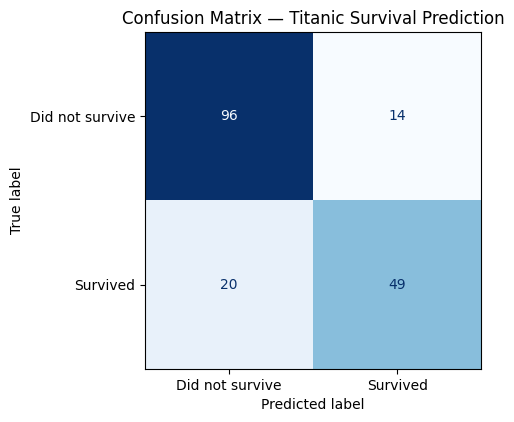

In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Titanic Survival Prediction")
plt.tight_layout()
plt.show()


## 8. What the confusion matrix tells us

The confusion matrix has 4 cells:

- **Top-left (True Negatives):** passengers who did **not** survive, and the
  model correctly predicted "did not survive."
- **Top-right (False Positives):** passengers who did **not** survive, but the
  model incorrectly predicted "survived."
- **Bottom-left (False Negatives):** passengers who **did** survive, but the
  model incorrectly predicted "did not survive."
- **Bottom-right (True Positives):** passengers who **did** survive, and the
  model correctly predicted "survived."

In this run, the model is noticeably better at correctly identifying passengers
who did **not** survive than those who did — the false-negative count (actual
survivors the model missed) is higher than the false-positive count. This
happens because slightly more than 60% of passengers did not survive, so the
model leans toward predicting "did not survive" when it's unsure. Accuracy
alone hides this imbalance, which is exactly why the confusion matrix (and
metrics like precision/recall) matter — a single accuracy number can look good
while the model is still systematically weaker on one class.


## 9. Full classification report (precision, recall, F1)

In [8]:
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))


                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 10. Which features mattered most?

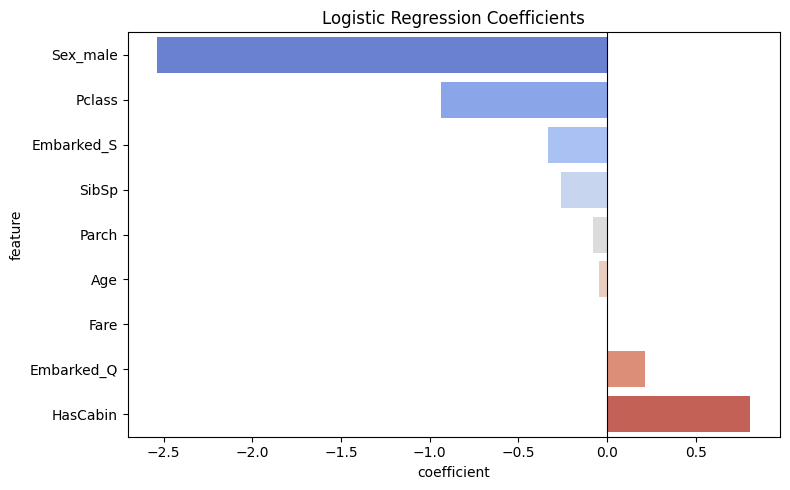

,feature,coefficient
6,Sex_male,-2.536164
0,Pclass,-0.933366
8,Embarked_S,-0.331888
2,SibSp,-0.261072
3,Parch,-0.080232
1,Age,-0.043554
4,Fare,0.001246
7,Embarked_Q,0.217091
5,HasCabin,0.808669


In [9]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(8, 5))
sns.barplot(x="coefficient", y="feature", data=coef_df, hue="feature", palette="coolwarm", legend=False)
plt.title("Logistic Regression Coefficients")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df


`Sex_male` has by far the largest negative coefficient, confirming what we saw
in Task 2's EDA: being male sharply reduces the predicted probability of
survival, all else equal. `Pclass` is also negative and meaningful (higher
class number = lower class = lower survival odds). This lines up with the
historical "women and children first" evacuation pattern.
